## 2.1.1. Thu thập và làm sạch dữ liệu giá BTC và S&P 500

Mục tiêu: nạp dữ liệu giá BTC và S&P 500 từ file Excel, giới hạn giai đoạn 2021-2024, trực quan hóa EDA bằng `cnsplots`, sau đó làm sạch dữ liệu để chuẩn bị tính returns.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cnsplots as cns

DATA_DIR = Path("data")
START_DATE = "2021-01-01"
END_DATE = "2024-12-31"

pd.set_option("display.float_format", "{:.2f}".format)

### Nạp dữ liệu và giới hạn giai đoạn 2021-2024

In [2]:
btc_raw = pd.read_excel(DATA_DIR / "CBBTCUSD.xlsx", sheet_name="Daily, 7-Day")
sp500_raw = pd.read_excel(DATA_DIR / "SP500.xlsx", sheet_name="Daily, Close")

btc = (
    btc_raw.rename(columns={"observation_date": "date", "CBBTCUSD": "BTC"})
    .assign(date=lambda df: pd.to_datetime(df["date"]))
    .loc[:, ["date", "BTC"]]
)

sp500 = (
    sp500_raw.rename(columns={"observation_date": "date", "SP500": "SP500"})
    .assign(date=lambda df: pd.to_datetime(df["date"]))
    .loc[:, ["date", "SP500"]]
)

btc_2021_2024 = btc.query("@START_DATE <= date <= @END_DATE").copy()
sp500_2021_2024 = sp500.query("@START_DATE <= date <= @END_DATE").copy()

raw_prices = (
    btc_2021_2024.merge(sp500_2021_2024, on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

display(raw_prices.head())
display(raw_prices.tail())

summary = pd.DataFrame(
    {
        "dataset": ["BTC", "S&P 500", "Merged raw"],
        "rows": [len(btc_2021_2024), len(sp500_2021_2024), len(raw_prices)],
        "start_date": [btc_2021_2024["date"].min(), sp500_2021_2024["date"].min(), raw_prices["date"].min()],
        "end_date": [btc_2021_2024["date"].max(), sp500_2021_2024["date"].max(), raw_prices["date"].max()],
        "missing_price_rows": [
            btc_2021_2024["BTC"].isna().sum(),
            sp500_2021_2024["SP500"].isna().sum(),
            raw_prices[["BTC", "SP500"]].isna().any(axis=1).sum(),
        ],
    }
)

display(summary)

,date,BTC,SP500
0,2021-01-01,29391.09,NaN
1,2021-01-04,32127.31,3700.65
2,2021-01-05,34131.23,3726.86
3,2021-01-06,36979.81,3748.14
4,2021-01-07,39573.39,3803.79


,date,BTC,SP500
1038,2024-12-25,95669.49,NaN
1039,2024-12-26,94171.89,6037.59
1040,2024-12-27,95130.82,5970.84
1041,2024-12-30,93354.22,5906.94
1042,2024-12-31,94383.59,5881.63


,dataset,rows,start_date,end_date,missing_price_rows
0,BTC,1461,2021-01-01,2024-12-31,0
1,S&P 500,1043,2021-01-01,2024-12-31,38
2,Merged raw,1043,2021-01-01,2024-12-31,38


### EDA bằng cnsplots

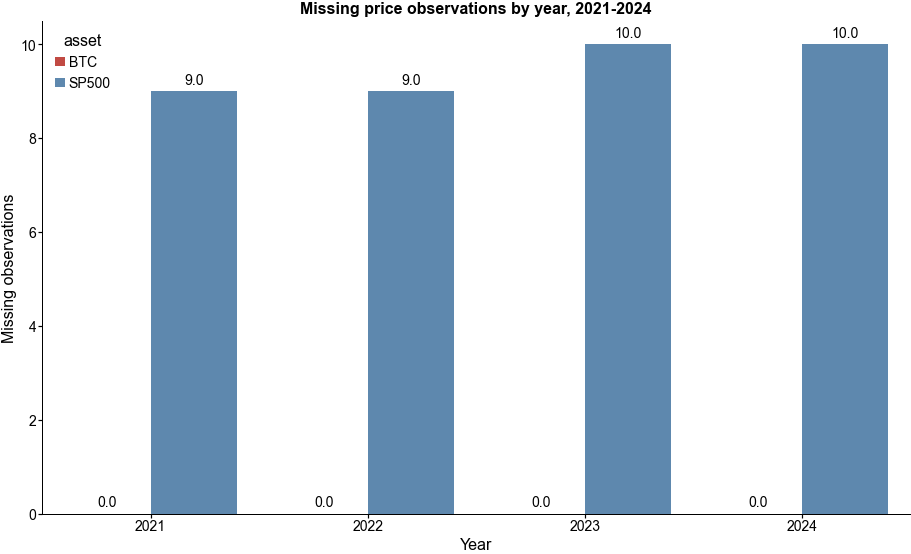

,year,asset,missing_count
0,2021,BTC,0
1,2022,BTC,0
2,2023,BTC,0
3,2024,BTC,0
4,2021,SP500,9
5,2022,SP500,9
6,2023,SP500,10
7,2024,SP500,10


In [3]:
missing_by_year = (
    raw_prices.assign(year=raw_prices["date"].dt.year)
    .set_index("year")[["BTC", "SP500"]]
    .isna()
    .groupby(level=0)
    .sum()
    .reset_index()
    .melt(id_vars="year", var_name="asset", value_name="missing_count")
)

cns.figure(width=560, height=320)
ax = cns.barplot(data=missing_by_year, x="year", y="missing_count", hue="asset", add_tip=True)
ax.set(
    title="Missing price observations by year, 2021-2024",
    xlabel="Year",
    ylabel="Missing observations",
)
plt.show()

display(missing_by_year)

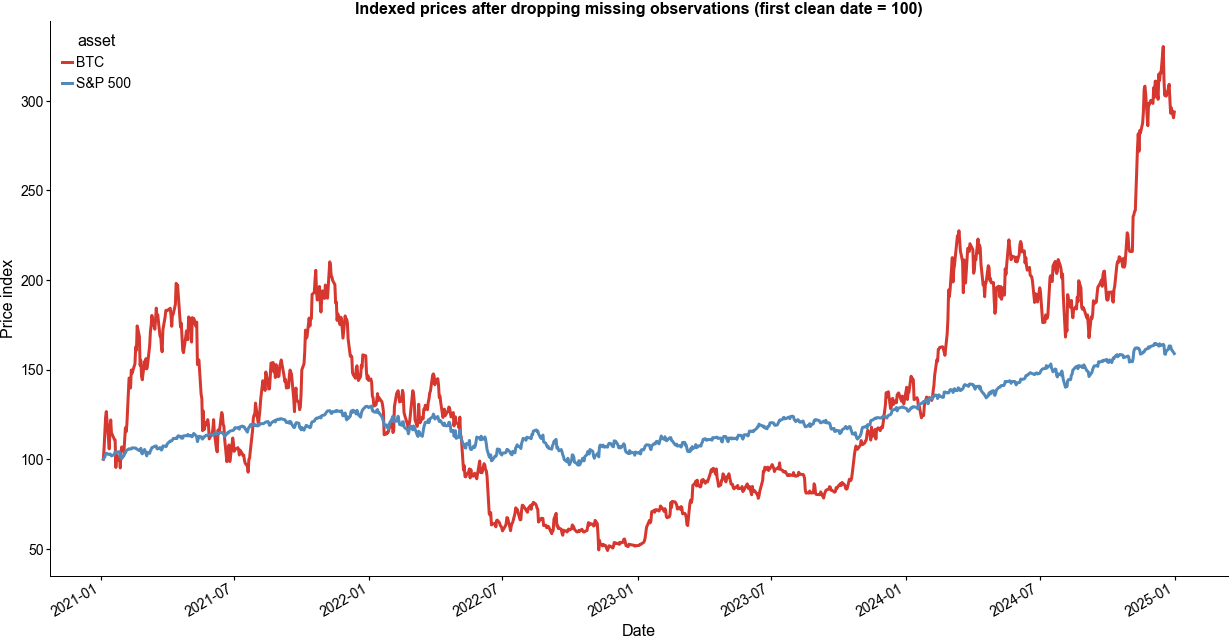

In [4]:
observed_prices = raw_prices.dropna(subset=["BTC", "SP500"]).copy()

indexed_prices = observed_prices.assign(
    BTC_index=observed_prices["BTC"] / observed_prices["BTC"].iloc[0] * 100,
    SP500_index=observed_prices["SP500"] / observed_prices["SP500"].iloc[0] * 100,
)

indexed_long = indexed_prices.melt(
    id_vars="date",
    value_vars=["BTC_index", "SP500_index"],
    var_name="asset",
    value_name="indexed_price",
)
indexed_long["asset"] = indexed_long["asset"].map({"BTC_index": "BTC", "SP500_index": "S&P 500"})

cns.figure(width=760, height=360)
ax = cns.lineplot(
    data=indexed_long,
    x="date",
    y="indexed_price",
    hue="asset",
    estimator=None,
    errorbar=None,
)
ax.set(
    title="Indexed prices after dropping missing observations (first clean date = 100)",
    xlabel="Date",
    ylabel="Price index",
)
plt.xticks(rotation=30, ha="right")
plt.show()

### Làm sạch dữ liệu sau EDA

EDA cho thấy BTC không thiếu giá trong giai đoạn 2021-2024. Các dòng thiếu nằm ở S&P 500, chủ yếu là ngày thị trường Mỹ không giao dịch. Vì mục tiêu tiếp theo là so sánh returns giữa BTC và S&P 500 trên cùng mốc thời gian, ta loại các dòng không có đủ cả hai giá thay vì nội suy giá chứng khoán vào ngày nghỉ.

In [5]:
clean_prices = (
    raw_prices.dropna(subset=["BTC", "SP500"])
    .drop_duplicates(subset="date")
    .sort_values("date")
    .reset_index(drop=True)
)

cleaning_report = pd.DataFrame(
    {
        "metric": [
            "raw_rows",
            "removed_rows_with_missing_price",
            "clean_rows",
            "clean_start_date",
            "clean_end_date",
            "duplicate_dates_after_cleaning",
            "missing_values_after_cleaning",
            "non_positive_prices_after_cleaning",
        ],
        "value": [
            len(raw_prices),
            len(raw_prices) - len(clean_prices),
            len(clean_prices),
            clean_prices["date"].min(),
            clean_prices["date"].max(),
            clean_prices["date"].duplicated().sum(),
            clean_prices[["BTC", "SP500"]].isna().sum().sum(),
            (clean_prices[["BTC", "SP500"]] <= 0).sum().sum(),
        ],
    }
)

display(cleaning_report)
display(clean_prices.head())
display(clean_prices.tail())

,metric,value
0,raw_rows,1043
1,removed_rows_with_missing_price,38
2,clean_rows,1005
3,clean_start_date,2021-01-04 00:00:00
4,clean_end_date,2024-12-31 00:00:00
5,duplicate_dates_after_cleaning,0
6,missing_values_after_cleaning,0
7,non_positive_prices_after_cleaning,0


,date,BTC,SP500
0,2021-01-04,32127.31,3700.65
1,2021-01-05,34131.23,3726.86
2,2021-01-06,36979.81,3748.14
3,2021-01-07,39573.39,3803.79
4,2021-01-08,40666.72,3824.68


,date,BTC,SP500
1000,2024-12-24,99346.28,6040.04
1001,2024-12-26,94171.89,6037.59
1002,2024-12-27,95130.82,5970.84
1003,2024-12-30,93354.22,5906.94
1004,2024-12-31,94383.59,5881.63


## 2.1.2. Tính Simple Returns và Log Returns

Sử dụng `clean_prices` từ bước 2.1.1 để tính returns trên cùng lịch giao dịch đã làm sạch.

### Simple Returns

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1
$$

Trong đó $P_t$ là giá tại thời điểm $t$, còn $P_{t-1}$ là giá ở kỳ liền trước.

In [6]:
returns_df = clean_prices.copy()

returns_df["BTC_simple_return"] = returns_df["BTC"].pct_change()
returns_df["SP500_simple_return"] = returns_df["SP500"].pct_change()

simple_return_cols = ["date", "BTC_simple_return", "SP500_simple_return"]
display(returns_df[simple_return_cols].head())
display(returns_df[simple_return_cols].tail())

,date,BTC_simple_return,SP500_simple_return
0,2021-01-04,NaN,NaN
1,2021-01-05,0.06,0.01
2,2021-01-06,0.08,0.01
3,2021-01-07,0.07,0.01
4,2021-01-08,0.03,0.01


,date,BTC_simple_return,SP500_simple_return
1000,2024-12-24,0.01,0.01
1001,2024-12-26,-0.05,-0.00
1002,2024-12-27,0.01,-0.01
1003,2024-12-30,-0.02,-0.01
1004,2024-12-31,0.01,-0.00


### Log Returns

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})
$$

Log return thường được dùng trong phân tích tài chính vì có tính cộng dồn theo thời gian.

In [7]:
returns_df["BTC_log_return"] = np.log(returns_df["BTC"] / returns_df["BTC"].shift(1))
returns_df["SP500_log_return"] = np.log(returns_df["SP500"] / returns_df["SP500"].shift(1))

log_return_cols = ["date", "BTC_log_return", "SP500_log_return"]
display(returns_df[log_return_cols].head())
display(returns_df[log_return_cols].tail())

,date,BTC_log_return,SP500_log_return
0,2021-01-04,NaN,NaN
1,2021-01-05,0.06,0.01
2,2021-01-06,0.08,0.01
3,2021-01-07,0.07,0.01
4,2021-01-08,0.03,0.01


,date,BTC_log_return,SP500_log_return
1000,2024-12-24,0.01,0.01
1001,2024-12-26,-0.05,-0.00
1002,2024-12-27,0.01,-0.01
1003,2024-12-30,-0.02,-0.01
1004,2024-12-31,0.01,-0.00


### Bộ dữ liệu returns hoàn chỉnh

Dòng đầu tiên không có kỳ trước để tính returns, nên bị loại khỏi `returns_clean`.

In [8]:
returns_clean = returns_df.dropna(
    subset=[
        "BTC_simple_return",
        "SP500_simple_return",
        "BTC_log_return",
        "SP500_log_return",
    ]
).reset_index(drop=True)

returns_report = pd.DataFrame(
    {
        "metric": [
            "price_rows",
            "return_rows_after_dropping_first_row",
            "return_start_date",
            "return_end_date",
            "missing_values_after_return_calculation",
        ],
        "value": [
            len(clean_prices),
            len(returns_clean),
            returns_clean["date"].min(),
            returns_clean["date"].max(),
            returns_clean[
                [
                    "BTC_simple_return",
                    "SP500_simple_return",
                    "BTC_log_return",
                    "SP500_log_return",
                ]
            ].isna().sum().sum(),
        ],
    }
)

display(returns_report)
display(returns_clean.head())
display(returns_clean.tail())

,metric,value
0,price_rows,1005
1,return_rows_after_dropping_first_row,1004
2,return_start_date,2021-01-05 00:00:00
3,return_end_date,2024-12-31 00:00:00
4,missing_values_after_return_calculation,0


,date,BTC,SP500,BTC_simple_return,SP500_simple_return,BTC_log_return,SP500_log_return
0,2021-01-05,34131.23,3726.86,0.06,0.01,0.06,0.01
1,2021-01-06,36979.81,3748.14,0.08,0.01,0.08,0.01
2,2021-01-07,39573.39,3803.79,0.07,0.01,0.07,0.01
3,2021-01-08,40666.72,3824.68,0.03,0.01,0.03,0.01
4,2021-01-11,35474.31,3799.61,-0.13,-0.01,-0.14,-0.01


,date,BTC,SP500,BTC_simple_return,SP500_simple_return,BTC_log_return,SP500_log_return
999,2024-12-24,99346.28,6040.04,0.01,0.01,0.01,0.01
1000,2024-12-26,94171.89,6037.59,-0.05,-0.00,-0.05,-0.00
1001,2024-12-27,95130.82,5970.84,0.01,-0.01,0.01,-0.01
1002,2024-12-30,93354.22,5906.94,-0.02,-0.01,-0.02,-0.01
1003,2024-12-31,94383.59,5881.63,0.01,-0.00,0.01,-0.00


## 2.1.3. Thống kê mô tả dữ liệu giá và returns

Phần này tổng hợp các chỉ số mô tả cho dữ liệu giá đã làm sạch và dữ liệu returns đã tính ở bước trước.

In [9]:
def descriptive_stats(df, columns, scale=1.0):
    data = df[columns] * scale
    stats = pd.DataFrame(
        {
            "count": data.count(),
            "mean": data.mean(),
            "median": data.median(),
            "min": data.min(),
            "q1_25%": data.quantile(0.25),
            "q3_75%": data.quantile(0.75),
            "max": data.max(),
            "std_dev": data.std(),
            "variance": data.var    (),
            "avg_abs_dev": data.sub(data.mean()).abs().mean(),
            "skewness": data.skew(),
            "kurtosis": data.kurt(),
        }
    )
    return stats.round(4)

### Thống kê mô tả dữ liệu giá

Các chỉ số dưới đây được tính trên `clean_prices`, sau khi đã loại các ngày thiếu giá BTC hoặc S&P 500.

In [10]:
price_stats = descriptive_stats(clean_prices, ["BTC", "SP500"])
display(price_stats)

,count,mean,median,min,q1_25%,q3_75%,max,std_dev,variance,avg_abs_dev,skewness,kurtosis
BTC,1005,42708.92,39993.11,15755.75,27324.09,57384.82,106136.99,18844.72,355123628.41,15399.12,0.78,0.33
SP500,1005,4521.86,4382.78,3577.03,4080.11,4778.73,6090.27,607.86,369498.64,480.85,0.90,-0.08


### Thống kê mô tả returns

Returns được nhân `100` để hiển thị theo đơn vị phần trăm (%), giúp bảng dễ đọc hơn.

In [11]:
return_columns = [
    "BTC_simple_return",
    "SP500_simple_return",
    "BTC_log_return",
    "SP500_log_return",
]

return_stats_pct = descriptive_stats(returns_clean, return_columns, scale=100)
display(return_stats_pct)

,count,mean,median,min,q1_25%,q3_75%,max,std_dev,variance,avg_abs_dev,skewness,kurtosis
BTC_simple_return,1004,0.19,0.03,-23.15,-1.82,2.05,21.62,3.95,15.63,2.78,0.05,3.76
SP500_simple_return,1004,0.05,0.07,-4.32,-0.50,0.65,5.54,1.04,1.08,0.76,-0.21,1.93
BTC_log_return,1004,0.11,0.03,-26.34,-1.84,2.03,19.57,3.96,15.69,2.77,-0.30,4.29
SP500_log_return,1004,0.05,0.07,-4.42,-0.50,0.65,5.40,1.04,1.08,0.76,-0.27,1.94


### Nhận xét nhanh

- `std_dev`, `variance`, và `avg_abs_dev` đo mức độ biến động của chuỗi giá hoặc returns.
- `skewness` cho biết phân phối lệch trái/phải.
- `kurtosis` cho biết mức độ đuôi dày so với phân phối chuẩn.

## 2.2. Trực Quan Hóa Dữ Liệu

Phần này trực quan hóa dữ liệu giá và returns đã làm sạch/tính toán ở phần 2.1. Các biểu đồ sử dụng `cnsplots`.

In [12]:
MARCH_2023_START = pd.Timestamp("2023-03-01")
MARCH_2023_END = pd.Timestamp("2023-03-31")

price_indexed = clean_prices.assign(
    BTC_index=clean_prices["BTC"] / clean_prices["BTC"].iloc[0] * 100,
    SP500_index=clean_prices["SP500"] / clean_prices["SP500"].iloc[0] * 100,
)

price_indexed_long = price_indexed.melt(
    id_vars="date",
    value_vars=["BTC_index", "SP500_index"],
    var_name="asset",
    value_name="price_index",
)
price_indexed_long["asset"] = price_indexed_long["asset"].map(
    {"BTC_index": "BTC", "SP500_index": "S&P 500"}
)

return_ts_long = returns_clean.melt(
    id_vars="date",
    value_vars=["BTC_log_return", "SP500_log_return"],
    var_name="asset",
    value_name="log_return_pct",
)
return_ts_long["asset"] = return_ts_long["asset"].map(
    {"BTC_log_return": "BTC", "SP500_log_return": "S&P 500"}
)
return_ts_long["log_return_pct"] *= 100

### 2.2.1. Biểu đồ chuỗi thời gian của giá và returns

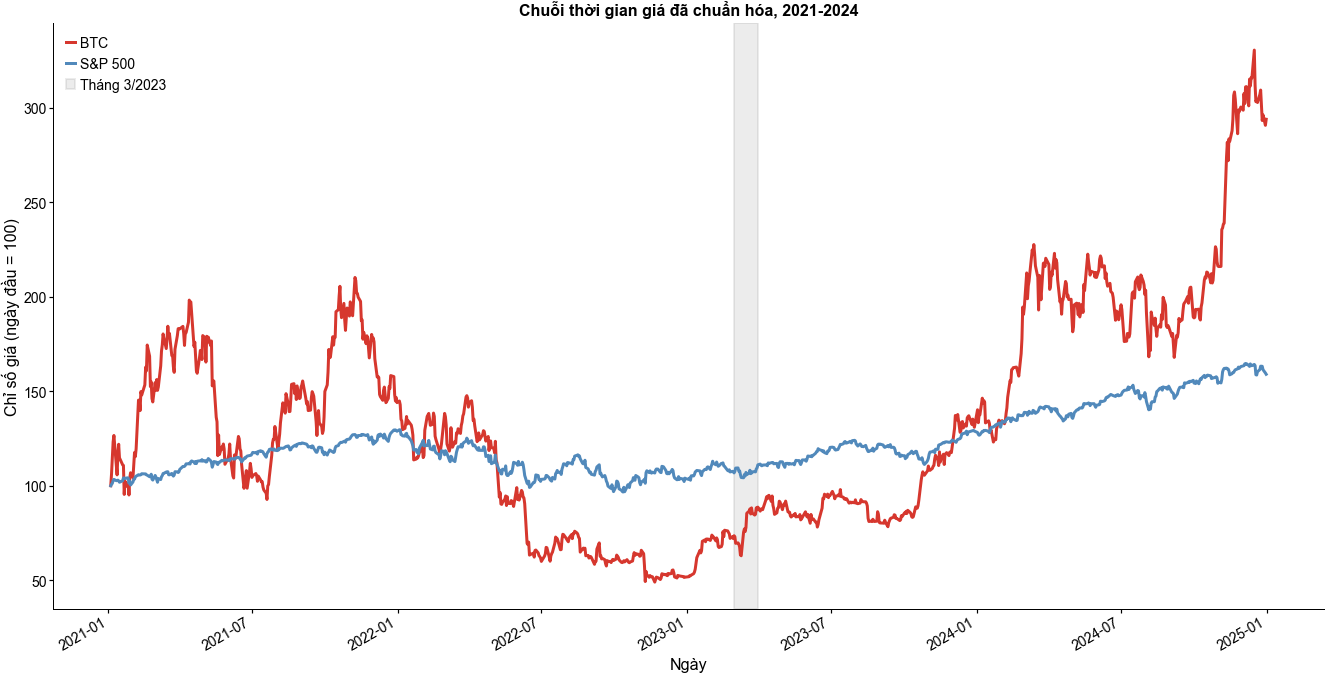

In [13]:
cns.figure(width=820, height=380)
ax = cns.lineplot(
    data=price_indexed_long,
    x="date",
    y="price_index",
    hue="asset",
    estimator=None,
    errorbar=None,
)
ax.axvspan(MARCH_2023_START, MARCH_2023_END, color="gray", alpha=0.15, label="Tháng 3/2023")
ax.set(
    title="Chuỗi thời gian giá đã chuẩn hóa, 2021-2024",
    xlabel="Ngày",
    ylabel="Chỉ số giá (ngày đầu = 100)",
)
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.show()

In [14]:
simple_return_ts_long = returns_clean.melt(
    id_vars="date",
    value_vars=["BTC_simple_return", "SP500_simple_return"],
    var_name="asset",
    value_name="simple_return_pct",
)
simple_return_ts_long["asset"] = simple_return_ts_long["asset"].map(
    {"BTC_simple_return": "BTC", "SP500_simple_return": "S&P 500"}
)
simple_return_ts_long["simple_return_pct"] *= 100

cns.figure(width=820, height=380)
ax = cns.lineplot(
    data=simple_return_ts_long,
    x="date",
    y="simple_return_pct",
    hue="asset",
    estimator=None,
    errorbar=None,
    linewidth=0.9,
)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.axvspan(MARCH_2023_START, MARCH_2023_END, color="gray", alpha=0.15, label="Tháng 3/2023")
ax.set(
    title="Chuỗi thời gian simple returns theo ngày, 2021-2024",
    xlabel="Ngày",
    ylabel="Simple return (%)",
)
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.show()

In [15]:
cns.figure(width=820, height=380)
ax = cns.lineplot(
    data=return_ts_long,
    x="date",
    y="log_return_pct",
    hue="asset",
    estimator=None,
    errorbar=None,
    linewidth=0.9,
)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.axvspan(MARCH_2023_START, MARCH_2023_END, color="gray", alpha=0.15, label="Tháng 3/2023")
ax.set(
    title="Chuỗi thời gian log returns theo ngày, 2021-2024",
    xlabel="Ngày",
    ylabel="Log return (%)",
)
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.show()

### 2.2.2. Histogram phân phối returns

In [16]:
simple_return_hist = returns_clean.melt(
    value_vars=["BTC_simple_return", "SP500_simple_return"],
    var_name="asset",
    value_name="simple_return_pct",
)
simple_return_hist["asset"] = simple_return_hist["asset"].map(
    {"BTC_simple_return": "BTC", "SP500_simple_return": "S&P 500"}
)
simple_return_hist["simple_return_pct"] *= 100

cns.figure(width=720, height=380)
ax = cns.histplot(
    data=simple_return_hist,
    x="simple_return_pct",
    hue="asset",
    bins=70,
    stat="density",
    common_norm=False,
    multiple="layer",
    fill=True,
    kde=True,
    alpha=0.35,
)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set(
    title="Phân phối simple returns theo ngày",
    xlabel="Simple return (%)",
    ylabel="Mật độ",
)
plt.show()

In [17]:
log_return_hist = returns_clean.melt(
    value_vars=["BTC_log_return", "SP500_log_return"],
    var_name="asset",
    value_name="log_return_pct",
)
log_return_hist["asset"] = log_return_hist["asset"].map(
    {"BTC_log_return": "BTC", "SP500_log_return": "S&P 500"}
)
log_return_hist["log_return_pct"] *= 100

cns.figure(width=720, height=380)
ax = cns.histplot(
    data=log_return_hist,
    x="log_return_pct",
    hue="asset",
    bins=70,
    stat="density",
    common_norm=False,
    multiple="layer",
    fill=True,
    kde=True,
    alpha=0.35,
)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set(
    title="Phân phối log returns theo ngày",
    xlabel="Log return (%)",
    ylabel="Mật độ",
)
plt.show()

### 2.2.3. Nhận xét trực quan, đối chiếu mốc tháng 3 năm 2023

Mốc tháng 3/2023 được đánh dấu bằng vùng màu xám trên các biểu đồ chuỗi thời gian. Bên dưới là biểu đồ lợi suất cộng dồn trong riêng tháng 3/2023 và bảng tóm tắt để đối chiếu BTC với S&P 500.

In [18]:
march_2023_returns = returns_clean.loc[
    returns_clean["date"].between(MARCH_2023_START, MARCH_2023_END)
].copy()

march_2023_cum = march_2023_returns.assign(
    BTC_cumulative_return=(1 + march_2023_returns["BTC_simple_return"]).cumprod() - 1,
    SP500_cumulative_return=(1 + march_2023_returns["SP500_simple_return"]).cumprod() - 1,
)

march_2023_cum_long = march_2023_cum.melt(
    id_vars="date",
    value_vars=["BTC_cumulative_return", "SP500_cumulative_return"],
    var_name="asset",
    value_name="cumulative_return_pct",
)
march_2023_cum_long["asset"] = march_2023_cum_long["asset"].map(
    {"BTC_cumulative_return": "BTC", "SP500_cumulative_return": "S&P 500"}
)
march_2023_cum_long["cumulative_return_pct"] *= 100

cns.figure(width=720, height=360)
ax = cns.lineplot(
    data=march_2023_cum_long,
    x="date",
    y="cumulative_return_pct",
    hue="asset",
    estimator=None,
    errorbar=None,
    marker="o",
)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set(
    title="Lợi suất cộng dồn trong tháng 3/2023",
    xlabel="Ngày",
    ylabel="Cumulative simple return (%)",
)
plt.xticks(rotation=30, ha="right")
plt.show()

In [19]:
march_start_date = march_2023_returns["date"].min()
march_end_date = march_2023_returns["date"].max()

march_2023_summary = pd.DataFrame(
    {
        "asset": ["BTC", "S&P 500"],
        "observations": [len(march_2023_returns), len(march_2023_returns)],
        "start_price": [
            clean_prices.loc[clean_prices["date"] == march_start_date, "BTC"].iloc[0],
            clean_prices.loc[clean_prices["date"] == march_start_date, "SP500"].iloc[0],
        ],
        "end_price": [
            clean_prices.loc[clean_prices["date"] == march_end_date, "BTC"].iloc[0],
            clean_prices.loc[clean_prices["date"] == march_end_date, "SP500"].iloc[0],
        ],
        "monthly_simple_return_pct": [
            ((1 + march_2023_returns["BTC_simple_return"]).prod() - 1) * 100,
            ((1 + march_2023_returns["SP500_simple_return"]).prod() - 1) * 100,
        ],
        "avg_daily_simple_return_pct": [
            march_2023_returns["BTC_simple_return"].mean() * 100,
            march_2023_returns["SP500_simple_return"].mean() * 100,
        ],
        "daily_volatility_pct": [
            march_2023_returns["BTC_simple_return"].std() * 100,
            march_2023_returns["SP500_simple_return"].std() * 100,
        ],
        "max_daily_gain_pct": [
            march_2023_returns["BTC_simple_return"].max() * 100,
            march_2023_returns["SP500_simple_return"].max() * 100,
        ],
        "max_daily_loss_pct": [
            march_2023_returns["BTC_simple_return"].min() * 100,
            march_2023_returns["SP500_simple_return"].min() * 100,
        ],
    }
).round(4)

display(march_2023_summary)

,asset,observations,start_price,end_price,monthly_simple_return_pct,avg_daily_simple_return_pct,daily_volatility_pct,max_daily_gain_pct,max_daily_loss_pct
0,BTC,23,23634.46,28492.72,23.09,1.03,5.26,19.84,-6.21
1,S&P 500,23,3951.39,4109.31,3.51,0.16,1.13,1.76,-1.85


#### Nhận xét trực quan

- Trên biểu đồ giá chuẩn hóa, BTC biến động mạnh hơn S&P 500 trong toàn giai đoạn 2021-2024.
- Histogram returns cho thấy phân phối của BTC rộng hơn, phản ánh biến động ngày lớn hơn so với S&P 500.
- Riêng tháng 3/2023, đường cumulative return giúp đối chiếu trực tiếp hai tài sản: BTC có biên độ biến động và mức thay đổi cộng dồn nổi bật hơn S&P 500 trong cùng tháng.